# Secuencias y libro de órdenes: ¿hay señal solo en el libro?

Este cuaderno resume los experimentos secuenciales y convolucionales sobre el libro de órdenes. La pregunta es si, tratando el libro como un objeto con estructura espacio-temporal (en lugar de una tabla plana), el aprendizaje profundo encuentra una política rentable.

Las arquitecturas se inspiran en DeepLOB. Las ejecuciones pesadas viven en `scripts/experiments/` y sus métricas finales quedan en `results/key_results.csv`, que es lo que se carga aquí.

## Qué se evalúa

- **Tensor del libro** (10 primeros niveles × 8 pasos): auditoría de completitud.
- **GRU sobre secuencia tabular**: modela la dinámica temporal reciente.
- **BookEncoder (Conv1D)**: resume cada foto del libro con convoluciones + *pooling* dual.

Cada modelo se juzga por su **política económica** (neto tras coste), no por su acierto.

In [1]:
import pandas as pd
kr = pd.read_csv('../results/key_results.csv')
sel = kr[kr['experiment'].isin(['tensor_audit','tabular_gru','book_only_conv1d'])]
sel[['phase','experiment','metric','value','unit','status','interpretation']]

,phase,experiment,metric,value,unit,status,interpretation
5,sequence,tabular_gru,test_cost0p50_mean,0.4550,proxy_ticks,NO_GO,Signal remains but one bad test day
6,orderbook,tensor_audit,top10_complete,100,percent,GO,Orderbook tensor is model-ready
7,orderbook,book_only_conv1d,best_test_cost0p50_mean,-1.0830,proxy_ticks,NO_GO,Book alone is insufficient


## Política económica: representación sí, política no

La figura compara el neto económico (*proxy*, coste 0,5) de los dos enfoques sobre el libro. La GRU conserva una señal modesta, pero el modelo basado solo en el libro es claramente negativo: ninguno supera el umbral para considerarse una política rentable.

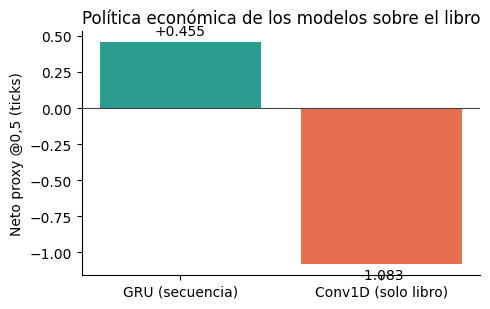

In [2]:
import matplotlib.pyplot as plt
m = (kr[kr['experiment'].isin(['tabular_gru','book_only_conv1d'])]
       .drop_duplicates('experiment').set_index('experiment')['value'])
vals = pd.to_numeric(m.reindex(['tabular_gru','book_only_conv1d']), errors='coerce')
labels = ['GRU (secuencia)','Conv1D (solo libro)']
cols = ['#2a9d8f' if v>=0 else '#e76f51' for v in vals.values]
fig, ax = plt.subplots(figsize=(5,3.2))
ax.bar(labels, vals.values, color=cols)
ax.axhline(0, color='#444', lw=0.8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_ylabel('Neto proxy @0,5 (ticks)')
ax.set_title('Política económica de los modelos sobre el libro')
for i,v in enumerate(vals.values):
    ax.annotate(f'{v:+.3f}', (i,v), ha='center', va='bottom' if v>=0 else 'top',
                xytext=(0,3 if v>=0 else -3), textcoords='offset points')
plt.tight_layout(); plt.show()

## Lectura

El tensor del libro está **completo** (100 %), de modo que la representación es válida. Sin embargo, ningún modelo profundo produce una política rentable: la GRU conserva señal pero cae en un día malo del test (`NO_GO`), y el libro por sí solo es **insuficiente** (neto *proxy* $-1{,}083$ a coste 0,5, `NO_GO`).

La conclusión, coherente con la memoria, es que **el aprendizaje profundo aporta representación pero no una política estable** con unas dos semanas de datos. Por eso el candidato final será un modelo tabular regularizado, no una red. Detalle en `docs/10_secuencias_y_orderbook.md`.